In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Seed
random.seed(42)
np.random.seed(42)

In [3]:
# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'time_series', 'real', 'daily_climate')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints''time_series', 'real', 'daily_climate')
OUT_PATH = os.path.join(CURRENT_DIR, 'out' 'time_series', 'real', 'daily_climate')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'

In [4]:
df_train = pd.read_csv(os.path.join(DATA_PATH, 'DailyDelhiClimateTrain.csv'))
df_test = pd.read_csv(os.path.join(DATA_PATH, 'DailyDelhiClimateTest.csv'))
df_data = pd.concat([df_train, df_test], axis=0)
df_data.shape, df_train.shape, df_test.shape

((1576, 5), (1462, 5), (114, 5))

In [5]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
meantemp,1576.0,25.221918,7.345014,6.000000,18.500,27.166667,31.142857,38.714286
humidity,1576.0,60.445229,16.979994,13.428571,49.750,62.440476,72.125000,100.000000
wind_speed,1576.0,6.899262,4.510725,0.000000,3.700,6.363571,9.262500,42.220000
meanpressure,1576.0,1010.593178,175.242704,-3.041667,1001.875,1009.055556,1015.200000,7679.333333


In [6]:
df_data['date'] = pd.to_datetime(df_data['date'])

In [7]:
df_data.nunique()

date            1575
meantemp         670
humidity         978
wind_speed       803
meanpressure     679
dtype: int64

In [8]:
print(df_data['date'].unique())

<DatetimeArray>
['2013-01-01 00:00:00', '2013-01-02 00:00:00', '2013-01-03 00:00:00',
 '2013-01-04 00:00:00', '2013-01-05 00:00:00', '2013-01-06 00:00:00',
 '2013-01-07 00:00:00', '2013-01-08 00:00:00', '2013-01-09 00:00:00',
 '2013-01-10 00:00:00',
 ...
 '2017-04-15 00:00:00', '2017-04-16 00:00:00', '2017-04-17 00:00:00',
 '2017-04-18 00:00:00', '2017-04-19 00:00:00', '2017-04-20 00:00:00',
 '2017-04-21 00:00:00', '2017-04-22 00:00:00', '2017-04-23 00:00:00',
 '2017-04-24 00:00:00']
Length: 1575, dtype: datetime64[ns]


In [9]:
df_data.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [10]:
df_data.duplicated().sum()

0

In [11]:
df_data.set_index('date', inplace=True)

In [12]:
df_data['y'] = df_data['wind_speed']
df_data.drop(columns=['wind_speed'], inplace=True)

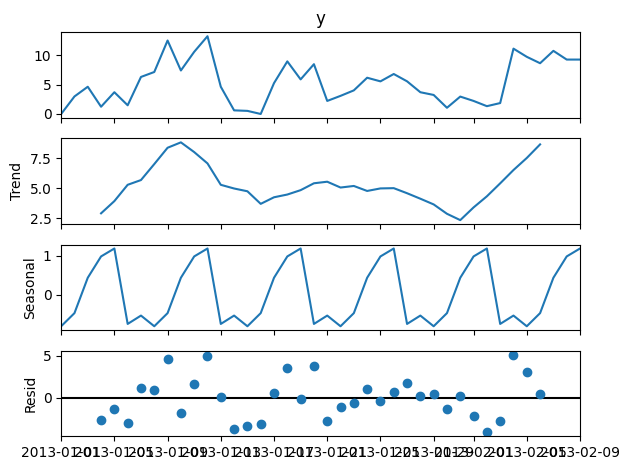

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(df_data['y'].iloc[:40], model="additive")
decomposition.plot()
plt.show()

In [53]:
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    )
)